# Assignment 1 (Coding Part)

- Implement the required code for each problem in the allocated area.
- Write down your comments clearly.
- Please submit your notebook with outputs displayed.

## Exercise 1.10

In [2]:
import random
num_coins = 1000
num_flips = 10
num_experiments = 100000

def flip_coin():
    # TODO: add fair coin flipping experiment code
    return [random.choice(['H', 'T']) for _ in range(num_flips)]

def experiment():
    all_coins =[]
    for i in range(num_coins):
        all_coins.append(flip_coin())

    c1 = all_coins[0]
    c_rand = all_coins[random.randint(0,num_coins-1)]
    c_min = min(all_coins, key=lambda coin: coin.count('H'))

    nu1 = c1.count('H') / num_flips
    nu_rand = c_rand.count('H') / num_flips
    nu_min = c_min.count('H') / num_flips

    return nu1,nu_rand,nu_min

### Exercise 1.10 (a)

In [3]:
# TODO: add solution for point a
mu1 = mu_rand = mu_min = 0.5
# Because all of them are fair coins, their mu is always 0.5 but their nu kan vary due to randomness

### Exercise 1.10 (b)

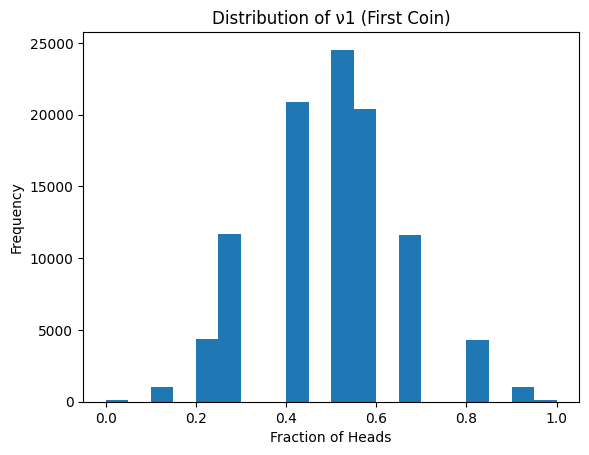

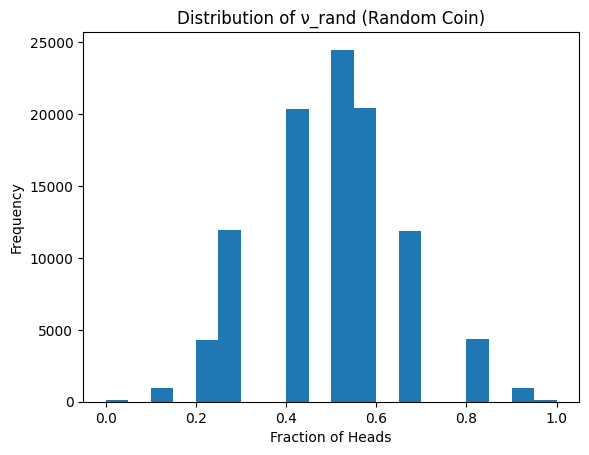

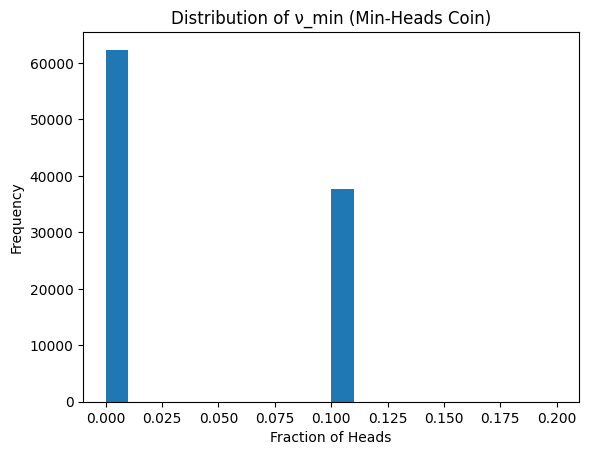

In [4]:
# TODO: add solution for point b
import numpy as np
import matplotlib.pyplot as plt

nu1_values = []
nu_rand_values = []
nu_min_values = []

for _ in range(num_experiments):

    nu1,nu_rand,nu_min = experiment()
    nu1_values.append(nu1)
    nu_rand_values.append(nu_rand)
    nu_min_values.append(nu_min)
    

plt.hist(nu1_values, bins=20)
plt.title("Distribution of ν1 (First Coin)")
plt.xlabel("Fraction of Heads")
plt.ylabel("Frequency")
plt.show()

plt.hist(nu_rand_values, bins=20)
plt.title("Distribution of ν_rand (Random Coin)")
plt.xlabel("Fraction of Heads")
plt.ylabel("Frequency")
plt.show()

plt.hist(nu_min_values, bins=20)
plt.title("Distribution of ν_min (Min-Heads Coin)")
plt.xlabel("Fraction of Heads")
plt.ylabel("Frequency")
plt.show()

### Exercise 1.10 (c)

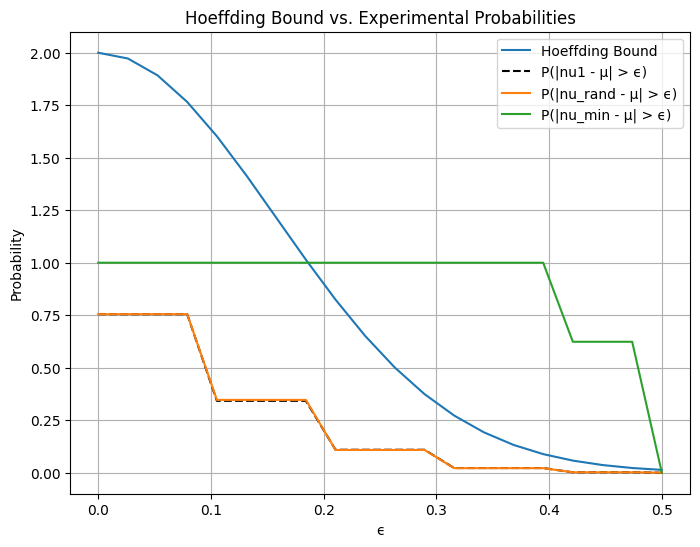

In [7]:
# TODO: add solution for point c
epsilons = np.linspace(0, 0.5, 20)

def get_prob(nu_values, epsilons):
    probs = []
    for epsilon in epsilons:
        probs.append(np.mean(np.abs(np.array(nu_values) - 0.5) > epsilon))
    return probs

prob_nu1 = get_prob(nu1_values, epsilons)
prob_nu_rand = get_prob(nu_rand_values, epsilons)
prob_nu_min = get_prob(nu_min_values, epsilons)

hoeffding_bound = 2 * np.exp(-2 * epsilons**2 * 10)


plt.figure(figsize=(8, 6))
plt.plot(epsilons, hoeffding_bound, label="Hoeffding Bound")
plt.plot(epsilons, prob_nu1, label="P(|nu1 - μ| > ϵ)", linestyle='dashed', color='black')
plt.plot(epsilons, prob_nu_rand, label="P(|nu_rand - μ| > ϵ)")
plt.plot(epsilons, prob_nu_min, label="P(|nu_min - μ| > ϵ)")

plt.xlabel("ϵ")
plt.ylabel("Probability")
plt.legend()
plt.title("Hoeffding Bound vs. Experimental Probabilities")
plt.grid()
plt.show()

### Exercise 1.10 (d)

In [ ]:
# TODO: add solution for point d

# nu1 and nu_rand obeys hoefding bound but nu_min does not. 
# Hoeffding inequality applies when choosing a single fixed hypothesis before seeing the data
# since nu1 and nu_rand are not chosen based on their outcome, they satisfy Hoeffding’s bound
# but nu_min is based on the data, so it does not satisfy Hoeffding’s bound, it's like we're chosing a specific coin after seeing the data

### Exercise 1.10 (e)

In [ ]:
# TODO: add solution for point e
# a bin represents a hypothesis from a set of M hypotheses
# and the number of red marbles in the bin represents the number of heads that coin got
# c1 and c_rand are like picking a random bin and c_min is like picking the bin with the least number of red marbles (best performing hypothesis)

# When M is small, Hoeffding’s bound holds well 
# As M increases, the bound gets looser
# But for nu_min, the bound does not hold because it is not chosen before seeing the data, it is chosen based on the data itself

## Problem 1.4

### Problem 1.4 (a)

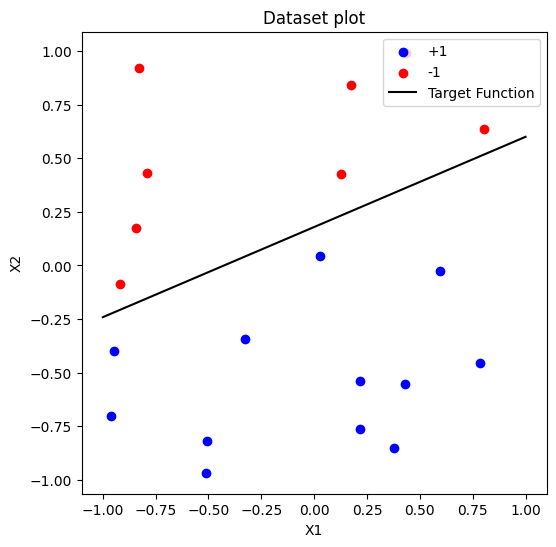

In [ ]:
def generate_dataset(N,d):
    # TODO: add dataset generation code
    f = np.random.randn(d + 1)
    matrix = np.random.uniform(-1, 1, (N, d)) 
    X = np.ones((N, d + 1))    
    X[:, 1:] = matrix  
    y= np.sign(np.dot(X, f))
    return X, y, f
    
def plot_dataset(X, y, f, final_weights = None):
    plt.figure(figsize=(6, 6))
    
    # Plot points
    plt.scatter(X[y == 1][:, 1], X[y == 1][:, 2], color='blue', label='+1')
    plt.scatter(X[y == -1][:, 1], X[y == -1][:, 2], color='red', label='-1')
    
    x1 = np.linspace(-1, 1, 100)
    x2 = -(f[1] * x1 + f[0]) / f[2]
    plt.plot(x1, x2, 'k-', label='Target Function')

    if final_weights is not None:
        x3 = -(final_weights[1] * x1 + final_weights[0]) / final_weights[2]
        plt.plot(x1, x3, 'g-', label='Final Hypothesis')
        
    plt.xlabel("X1")
    plt.ylabel("x3")
    plt.legend()
    plt.title("Dataset plot")
    plt.show()

x,y,f = generate_dataset(20,2)
plot_dataset(x, y, f)

### Problem 1.4 (b)

number of updates: 25


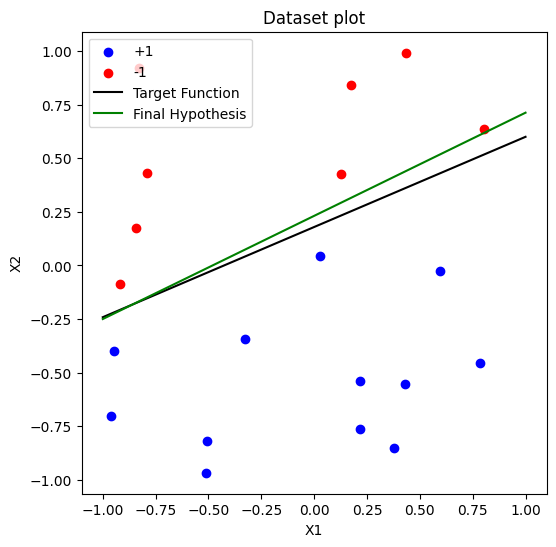

In [34]:
def run_perceptron_learning(x,y):
    # TODO: add perceptron learning algorithm code
    w = np.zeros(x.shape[1])
    updates = 0
    
    while True:
        m = 0
        for i in range(x.shape[0]):
            if y[i] * np.sign(np.dot(w.T, x[i])) <=0:
                w += y[i] * x[i]
                updates += 1
                m+=1
                break
        if m==0:
            break
    
    return w, updates

w, updates = run_perceptron_learning(x,y)
print("number of updates:",updates)

plot_dataset(x, y,f,w)


In [ ]:
# TODO: add solution for the rest of the point

# f is close to g with respect to discrimination between the two classes,
# but in some runs they are completely different lines but they both separate the data correctly

### Problem 1.4 (c)

number of updates: 9


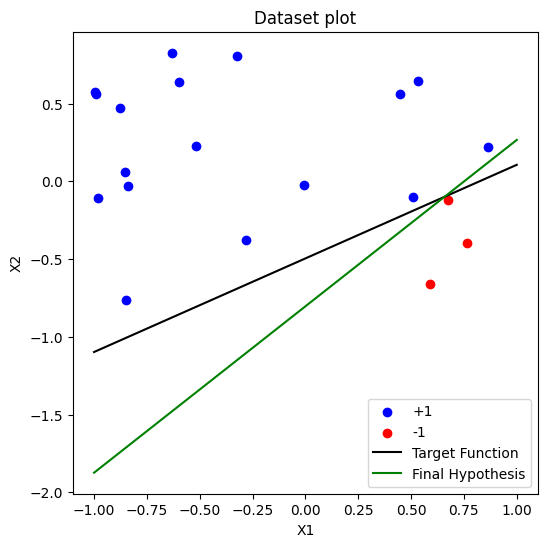

In [ ]:
# TODO: add solution for point c 
x2,y2,f2 = generate_dataset(20,2)
w2, updates2 = run_perceptron_learning(x2,y2)
print("number of updates:",updates2)

plot_dataset(x2, y2,f2,w2)

# g and f are not close for this dataset instance, but they both separate the classes correctly
# they are dependent on the dataset, they can be different and can be very close to each other

### Problem 1.4 (d)

number of updates: 495


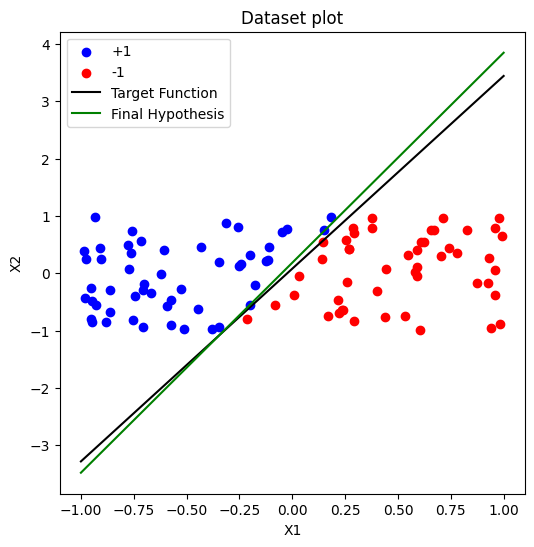

In [ ]:
# TODO: add solution for point d
x3,y3,f3 = generate_dataset(100,2)
w3, updates3 = run_perceptron_learning(x3,y3)
print("number of updates:",updates3)

plot_dataset(x3, y3,f3,w3)
# as the number of data points increases, the number of updates increases
# g and f are close to each other for this dataset instance
# they get closer as the number of updates increase

### Problem 1.4 (e)

number of updates: 855


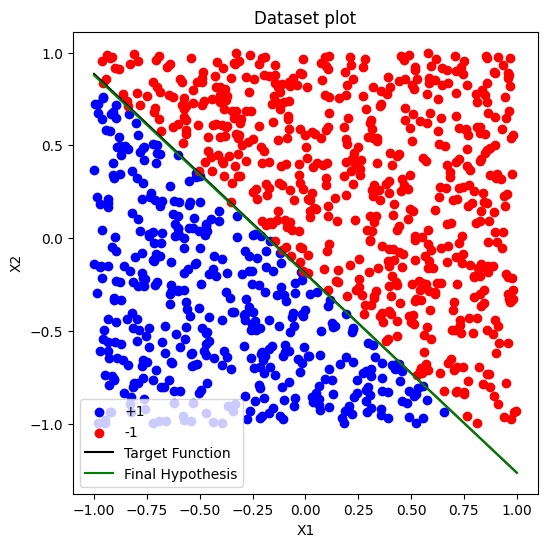

In [ ]:
# TODO: add solution for point e
x4,y4,f4 = generate_dataset(1000,2)
w4, updates4 = run_perceptron_learning(x4,y4)
print("number of updates:",updates4)

plot_dataset(x4, y4,f4,w4)
# as we can see g and f are almost the same
# they get closer as the number of updates increase and as the dataset gets larger

In [51]:
# TODO: add solution for point f
x5,y5,f5 = generate_dataset(1000,10)
w5, updates5 = run_perceptron_learning(x5,y5)
print("number of updates:",updates5)


number of updates: 5483


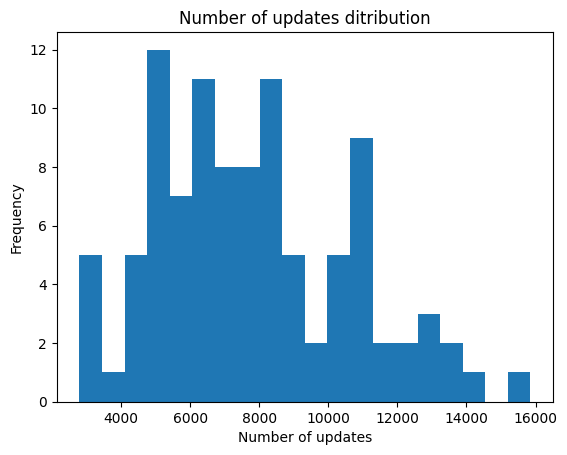

In [55]:
# TODO: add solution for point g
updates_list = []
for i in range(100):
    data = list(zip(x5,y5))
    np.random.shuffle(data)
    x6,y6 = zip(*data)
    w6, updates6 = run_perceptron_learning(np.array(x6),y6)
    updates_list.append(updates6)

plt.hist(updates_list, bins=20)
plt.title("Number of updates ditribution")
plt.xlabel("Number of updates")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# TODO: add solution for point h
# accuracy: as N,d increases, the number of updates increase, so the accuracy naturally increases
# runtime: as N,d increases, the number of iterations increase, so the runtime increases